# RQ3 Evaluation: Impact of Ranking Criteria on App Recommendations

**RQ3:** *To what extent do the ranking criteria reported by LLMs impact LLM mobile app recommendations?*

This notebook quantifies impact without ground-truth labels by measuring:

1. **Stability under the same criterion** (consistency across repeated runs).
2. **Shift from baseline behavior** (difference from RQ1 recommendations without explicit criterion).
3. **Distinctiveness across criteria** (whether different criteria produce genuinely different rankings).

If a criterion is stable across repeated runs and clearly different from baseline, we have evidence the model behavior changes due to that criterion.

In [95]:
from pathlib import Path
import json
import re
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)


def detect_repo_root(start: Path) -> Path:
    cur = start.resolve()
    candidates = [cur, *cur.parents]
    for c in candidates:
        if (c / "data/output/features/rq1").exists() and (c / "data/output/features/rq3").exists():
            return c
    raise FileNotFoundError("Could not find repo root containing data/output/features/rq1 and rq3")


ROOT = detect_repo_root(Path.cwd())
RQ1_DIR = ROOT / "data/output/features/rq1"
RQ3_DIR = ROOT / "data/output/features/rq3"

print("Repo root:", ROOT)
print("RQ1 exists:", RQ1_DIR.exists(), "| RQ3 exists:", RQ3_DIR.exists())

Repo root: C:\Users\joaquim.motger\Projectes\llm-recommender-system
RQ1 exists: True | RQ3 exists: True


In [96]:
def clean_app_name(name: str) -> str:
    """Normalize app names to reduce superficial spelling/casing differences."""
    if not isinstance(name, str):
        return ""
    s = name.strip().lower()
    s = s.replace("hbo max", "max")
    s = re.sub(r"\s+", " ", s)
    return s


def load_rankings(base_dir: Path, mode: str) -> pd.DataFrame:
    """
    mode='rq1': provider/feature/file where file like user-prompt-feature-rq1_3.json
    mode='rq3': provider/feature/file where file like Cost_0.json
    """
    rows = []
    for fp in base_dir.rglob("*.json"):
        parts = fp.relative_to(base_dir).parts
        if len(parts) < 3:
            continue

        provider, feature, file_name = parts[0], parts[1], parts[2]

        try:
            raw = json.loads(fp.read_text(encoding="utf-8"))
        except Exception:
            continue

        apps = raw.get("a", []) if isinstance(raw, dict) else []
        if not isinstance(apps, list):
            continue

        m = re.search(r"(\d+)\.json$", file_name)
        run = int(m.group(1)) if m else None

        criterion = "baseline"
        if mode == "rq3":
            criterion = re.sub(r"_\d+\.json$", "", file_name)

        norm_apps = [clean_app_name(x) for x in apps if clean_app_name(x)]

        rows.append(
            {
                "provider": provider,
                "feature": feature,
                "criterion": criterion,
                "run": run,
                "apps": norm_apps,
                "raw_path": str(fp),
            }
        )

    df = pd.DataFrame(rows)
    return df


def rbo_similarity(rank_a, rank_b, p=0.9, k=None):
    """Rank-Biased Overlap similarity in [0,1]. Robust to variable list lengths."""
    max_depth = min(len(rank_a), len(rank_b))
    if k is None:
        k = max_depth
    else:
        k = min(k, max_depth)

    if k == 0:
        return np.nan

    a_seen, b_seen = set(), set()
    overlap_sum = 0.0

    for d in range(1, k + 1):
        a_seen.add(rank_a[d - 1])
        b_seen.add(rank_b[d - 1])
        overlap = len(a_seen.intersection(b_seen)) / d
        overlap_sum += (p ** (d - 1)) * overlap

    return (1 - p) * overlap_sum


def topk_jaccard(rank_a, rank_b, k=10):
    sa, sb = set(rank_a[:k]), set(rank_b[:k])
    if not sa and not sb:
        return np.nan
    return len(sa.intersection(sb)) / len(sa.union(sb))

In [97]:
rq1 = load_rankings(RQ1_DIR, mode="rq1")
rq3 = load_rankings(RQ3_DIR, mode="rq3")

display(rq1.head(2))
display(rq3.head(2))

print("RQ1 rows:", len(rq1), "| RQ3 rows:", len(rq3))
print("Providers:", sorted(rq3["provider"].unique()))
print("Features:", rq3["feature"].nunique(), "| Criteria:", rq3["criterion"].nunique())
print("RQ1 runs:", sorted(rq1["run"].dropna().unique())[:15])
print("RQ3 runs:", sorted(rq3["run"].dropna().unique()))

,provider,feature,criterion,run,apps,raw_path
0,anthropic,k20_Access_to_movies,baseline,0,"[netflix, disney+, amazon prime video, max, hu...",C:\Users\joaquim.motger\Projectes\llm-recommen...
1,anthropic,k20_Access_to_movies,baseline,1,"[netflix, disney+, amazon prime video, max, hu...",C:\Users\joaquim.motger\Projectes\llm-recommen...


,provider,feature,criterion,run,apps,raw_path
0,anthropic,k20_Access_to_movies,Cost,0,"[tubi, crackle, pluto tv, imdb tv, vudu, youtu...",C:\Users\joaquim.motger\Projectes\llm-recommen...
1,anthropic,k20_Access_to_movies,Cost,1,"[tubi, crackle, pluto tv, imdb tv, vudu, popco...",C:\Users\joaquim.motger\Projectes\llm-recommen...


RQ1 rows: 800 | RQ3 rows: 6236
Providers: ['anthropic', 'gemini', 'mistral', 'openai', 'perplexity']
Features: 16 | Criteria: 16
RQ1 runs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
RQ3 runs: [0, 1, 2, 3, 4]


## 1) Baseline consensus (RQ1)

For each `(provider, feature)`, build a baseline consensus ranking from RQ1 runs. We use a simple **mean-rank aggregation**:

- each app gets rank per run,
- missing apps get penalized with rank `len(list)+1`,
- final score is mean rank (lower is better).

This consensus is the no-criterion reference for measuring re-ranking impact.

In [98]:
def build_consensus(runs_df: pd.DataFrame) -> dict:
    consensus = {}

    for (provider, feature), g in runs_df.groupby(["provider", "feature"]):
        lists = g["apps"].tolist()
        if not lists:
            continue

        all_apps = sorted(set(a for lst in lists for a in lst))
        max_len = max(len(lst) for lst in lists)
        default_rank = max_len + 1

        rows = []
        for lst in lists:
            pos = {app: i + 1 for i, app in enumerate(lst)}
            rows.append([pos.get(app, default_rank) for app in all_apps])

        rank_matrix = np.array(rows)
        mean_rank = rank_matrix.mean(axis=0)
        ranked = [app for app, _ in sorted(zip(all_apps, mean_rank), key=lambda x: x[1])]

        consensus[(provider, feature)] = ranked

    return consensus

baseline_consensus = build_consensus(rq1)
print("Baseline consensus profiles:", len(baseline_consensus))
print("Example key:", next(iter(baseline_consensus.keys())))

Baseline consensus profiles: 80
Example key: ('anthropic', 'k20_Access_to_movies')


## 2) Metric computation

We compute three metric families:

- **Stability** (`stability_rbo`, `stability_jaccard10`): average pairwise similarity among repeated RQ3 runs for the same `(provider, feature, criterion)`.
- **Shift from baseline** (`shift_rbo`, `shift_jaccard10`): dissimilarity between criterion runs and baseline consensus for same `(provider, feature)`.
- **Top-k novelty** (`novelty_top3`, `novelty_top10`, `novelty_top20`): fraction of criterion top-k apps absent from baseline top-k.

In [99]:
rows = []

for (provider, feature, criterion), g in rq3.groupby(["provider", "feature", "criterion"]):
    run_lists = g.sort_values("run")["apps"].tolist()
    if len(run_lists) < 2:
        continue

    # Stability across repeated runs for same criterion
    pair_rbo = []
    pair_j10 = []
    for a, b in combinations(run_lists, 2):
        pair_rbo.append(rbo_similarity(a, b, p=0.9, k=20))
        pair_j10.append(topk_jaccard(a, b, k=10))

    stability_rbo = float(np.nanmean(pair_rbo))
    stability_j10 = float(np.nanmean(pair_j10))

    # Shift vs baseline consensus from rq1
    baseline = baseline_consensus.get((provider, feature))
    if baseline is None:
        continue

    shift_rbo_runs = [1 - rbo_similarity(lst, baseline, p=0.9, k=20) for lst in run_lists]
    shift_j10_runs = [1 - topk_jaccard(lst, baseline, k=10) for lst in run_lists]

    def novelty_at_k(lst, base, k):
        topk = set(lst[:k])
        basek = set(base[:k])
        if not topk:
            return np.nan
        return len(topk - basek) / len(topk)

    novelty_top3_runs = [novelty_at_k(lst, baseline, 3) for lst in run_lists]
    novelty_top10_runs = [novelty_at_k(lst, baseline, 10) for lst in run_lists]
    novelty_top20_runs = [novelty_at_k(lst, baseline, 20) for lst in run_lists]

    rows.append(
        {
            "provider": provider,
            "feature": feature,
            "criterion": criterion,
            "n_runs": len(run_lists),
            "stability_rbo": stability_rbo,
            "stability_jaccard10": stability_j10,
            "shift_rbo": float(np.nanmean(shift_rbo_runs)),
            "shift_jaccard10": float(np.nanmean(shift_j10_runs)),
            "novelty_top3": float(np.nanmean(novelty_top3_runs)),
            "novelty_top10": float(np.nanmean(novelty_top10_runs)),
            "novelty_top20": float(np.nanmean(novelty_top20_runs)),
        }
    )

metrics = pd.DataFrame(rows)
print("Profiles with full metrics:", len(metrics))
display(metrics.head())

Profiles with full metrics: 1240


,provider,feature,criterion,n_runs,stability_rbo,stability_jaccard10,shift_rbo,shift_jaccard10,novelty_top3,novelty_top10,novelty_top20
0,anthropic,k20_Access_to_movies,Cost,5,0.752103,0.589744,0.897420,0.912281,1.0,0.84,0.33
1,anthropic,k20_Access_to_movies,Customer_Support,5,0.788437,0.812121,0.228802,0.303030,0.0,0.18,0.22
2,anthropic,k20_Access_to_movies,Customization_Options,5,0.754649,0.672194,0.995583,1.000000,1.0,1.00,0.91
3,anthropic,k20_Access_to_movies,Ease_of_Use,5,0.839069,0.866667,0.204359,0.303030,0.0,0.18,0.14
4,anthropic,k20_Access_to_movies,Feature_Set,5,0.807639,0.827273,0.195935,0.272727,0.0,0.16,0.14


## 3) Aggregated evidence for RQ3

Interpretation guideline:

- High `stability_rbo` + high `shift_rbo` => **criterion-driven controlled behavior change**.
- High `stability_rbo` + low `shift_rbo` => criterion has little impact.
- Low `stability_rbo` + high `shift_rbo` => behavior changes but noisily.

In [100]:
summary_provider = (
    metrics.groupby("provider")[["stability_rbo", "shift_rbo", "novelty_top3", "novelty_top10", "novelty_top20", "stability_jaccard10", "shift_jaccard10"]]
    .mean()
    .sort_values("shift_rbo", ascending=False)
)

display(summary_provider.style.format("{:.3f}"))

summary_criterion = (
    metrics.groupby("criterion")[["stability_rbo", "shift_rbo", "novelty_top3", "novelty_top10", "novelty_top20"]]
    .mean()
    .sort_values("shift_rbo", ascending=False)
)

display(summary_criterion.head(16).style.format("{:.3f}"))

,stability_rbo,shift_rbo,novelty_top3,novelty_top10,novelty_top20,stability_jaccard10,shift_jaccard10
provider,,,,,,,
perplexity,0.551,0.733,0.682,0.673,0.626,0.552,0.783
openai,0.550,0.634,0.615,0.526,0.521,0.555,0.651
gemini,0.494,0.531,0.459,0.445,0.487,0.451,0.575
anthropic,0.694,0.451,0.380,0.337,0.344,0.694,0.452
mistral,0.727,0.380,0.288,0.258,0.313,0.732,0.352


,stability_rbo,shift_rbo,novelty_top3,novelty_top10,novelty_top20
criterion,,,,,
Security_and_Privacy,0.526,0.777,0.775,0.700,0.663
Customization_Options,0.540,0.658,0.670,0.547,0.529
Integration_Capabilities,0.579,0.587,0.537,0.489,0.493
Monthly_Active_Users,0.649,0.568,0.494,0.469,0.479
In_App_Purchases,0.591,0.567,0.518,0.464,0.461
Cost,0.598,0.557,0.521,0.450,0.442
Number_of_Downloads,0.593,0.550,0.477,0.449,0.462
User_Base,0.659,0.538,0.448,0.442,0.458
Customer_Support,0.592,0.524,0.468,0.419,0.430


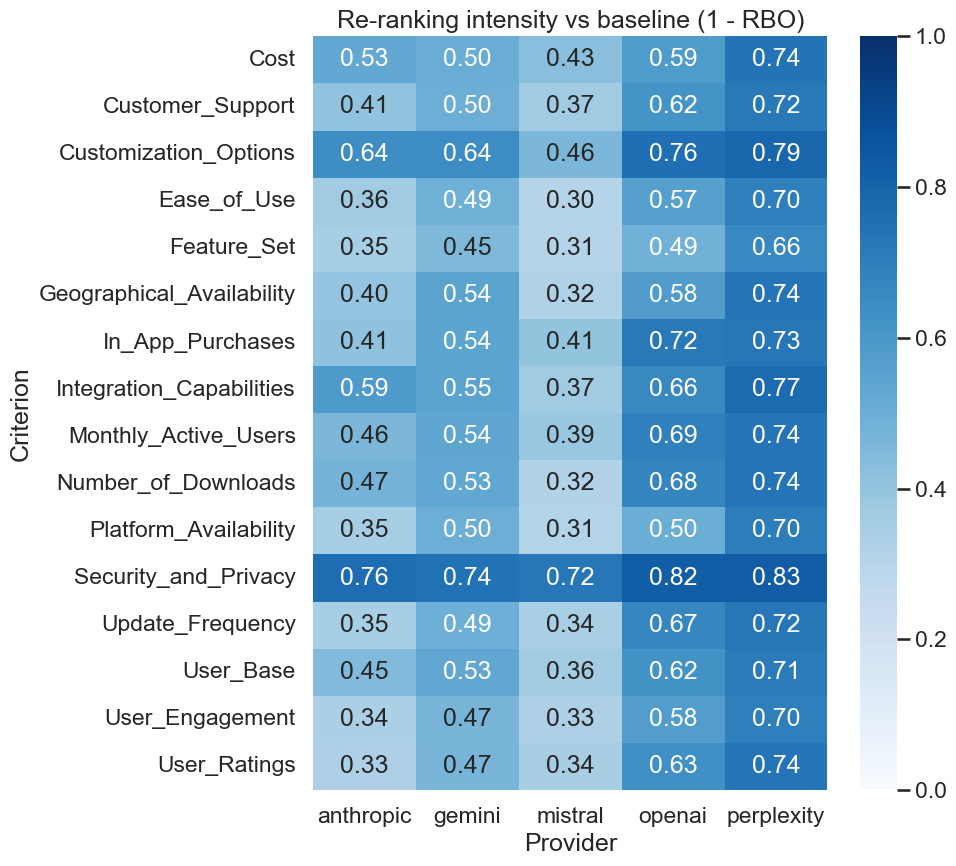

In [101]:
# Heatmap: mean re-ranking impact (shift_rbo) by provider and criterion
pivot_shift = metrics.pivot_table(index="criterion", columns="provider", values="shift_rbo", aggfunc="mean")

plt.figure(figsize=(10, 9))
sns.heatmap(pivot_shift, cmap="Blues", annot=True, fmt=".2f", vmin=0, vmax=1)
plt.title("Re-ranking intensity vs baseline (1 - RBO)")
plt.xlabel("Provider")
plt.ylabel("Criterion")
plt.tight_layout()
plt.show()

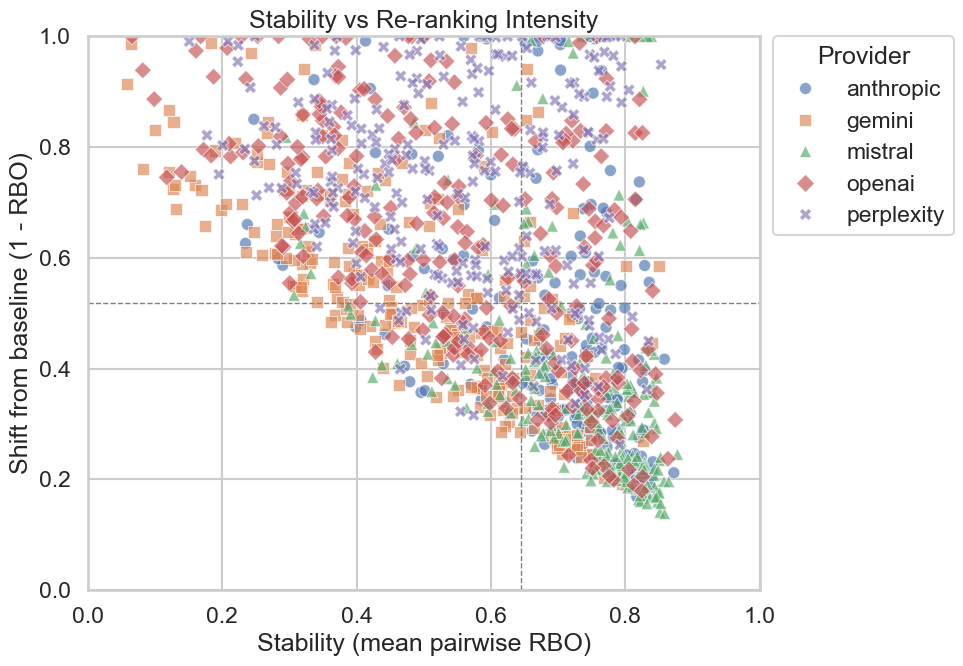

In [102]:
# Stability-impact map: each point is one (provider, feature, criterion) profile
plt.figure(figsize=(10, 7))
marker_map = {"anthropic": "o", "gemini": "s", "mistral": "^", "openai": "D", "perplexity": "X"}

ax = sns.scatterplot(
    data=metrics,
    x="stability_rbo",
    y="shift_rbo",
    hue="provider",
    style="provider",  # provider encoded by both color and marker shape
    markers=marker_map,
    alpha=0.65,
    s=75,
)

plt.axhline(metrics["shift_rbo"].median(), color="gray", linestyle="--", linewidth=1)
plt.axvline(metrics["stability_rbo"].median(), color="gray", linestyle="--", linewidth=1)
plt.title("Stability vs Re-ranking Intensity")
plt.xlabel("Stability (mean pairwise RBO)")
plt.ylabel("Shift from baseline (1 - RBO)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, title="Provider")
plt.tight_layout()
plt.show()

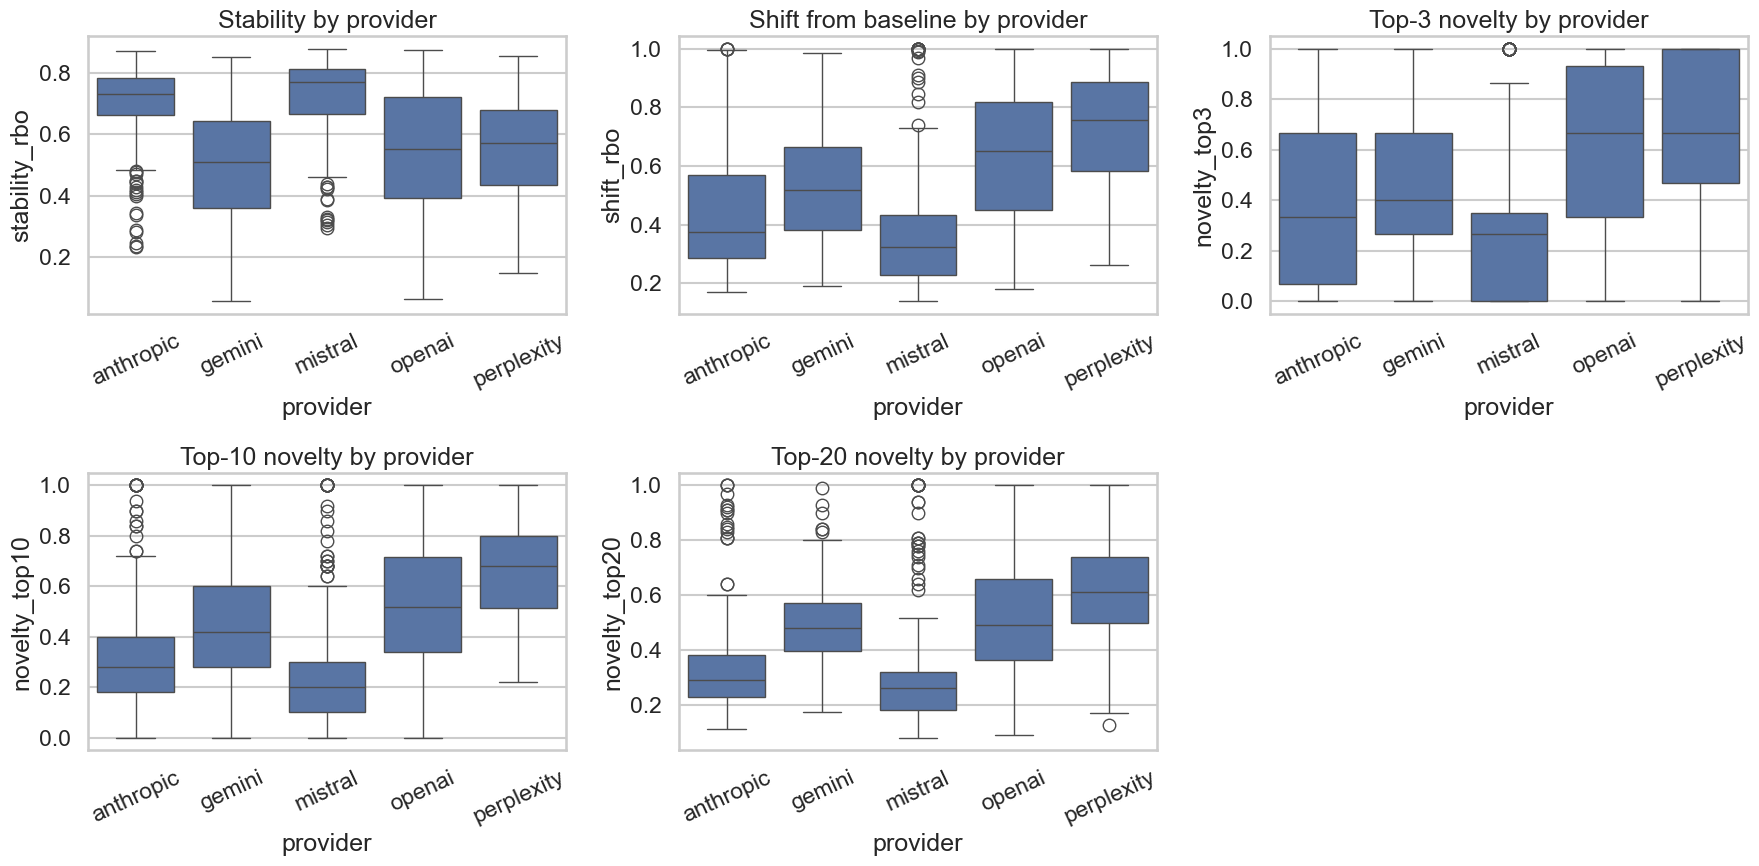

In [103]:
# Distribution by provider
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

sns.boxplot(data=metrics, x="provider", y="stability_rbo", ax=axes[0])
axes[0].set_title("Stability by provider")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=metrics, x="provider", y="shift_rbo", ax=axes[1])
axes[1].set_title("Shift from baseline by provider")
axes[1].tick_params(axis="x", rotation=25)

sns.boxplot(data=metrics, x="provider", y="novelty_top3", ax=axes[2])
axes[2].set_title("Top-3 novelty by provider")
axes[2].tick_params(axis="x", rotation=25)

sns.boxplot(data=metrics, x="provider", y="novelty_top10", ax=axes[3])
axes[3].set_title("Top-10 novelty by provider")
axes[3].tick_params(axis="x", rotation=25)

sns.boxplot(data=metrics, x="provider", y="novelty_top20", ax=axes[4])
axes[4].set_title("Top-20 novelty by provider")
axes[4].tick_params(axis="x", rotation=25)

axes[5].axis("off")

plt.tight_layout()
plt.show()

## 4) Criterion distinctiveness (within provider-feature)

Here we compare criterion consensuses against each other for each `(provider, feature)`.
If pairwise criterion dissimilarity is high, criteria are producing differentiated rankings.

Pairwise criterion comparisons: 9241


,mean_criterion_distance
provider,
openai,0.658063
perplexity,0.612720
anthropic,0.520882
gemini,0.494008
mistral,0.413208


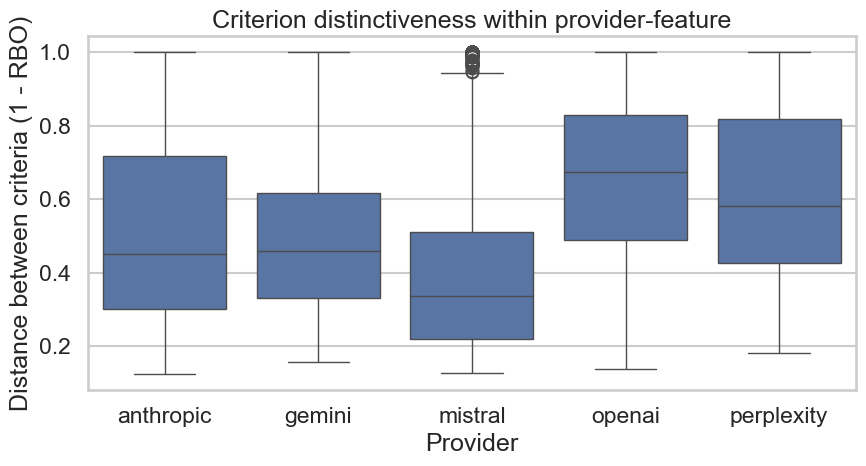

In [104]:
# Build consensus ranking per criterion from rq3 repeated runs
crit_consensus = {}
for (provider, feature, criterion), g in rq3.groupby(["provider", "feature", "criterion"]):
    # reuse build_consensus style on this small group
    lists = g["apps"].tolist()
    if len(lists) == 0:
        continue

    all_apps = sorted(set(a for lst in lists for a in lst))
    max_len = max(len(lst) for lst in lists)
    default_rank = max_len + 1

    matrix = []
    for lst in lists:
        pos = {a: i + 1 for i, a in enumerate(lst)}
        matrix.append([pos.get(a, default_rank) for a in all_apps])

    mean_rank = np.array(matrix).mean(axis=0)
    crit_consensus[(provider, feature, criterion)] = [a for a, _ in sorted(zip(all_apps, mean_rank), key=lambda x: x[1])]

# Pairwise criterion distance (1-RBO)
cd_rows = []
for (provider, feature), g in metrics.groupby(["provider", "feature"]):
    criteria = sorted(g["criterion"].unique())
    for c1, c2 in combinations(criteria, 2):
        r1 = crit_consensus.get((provider, feature, c1))
        r2 = crit_consensus.get((provider, feature, c2))
        if not r1 or not r2:
            continue
        dist = 1 - rbo_similarity(r1, r2, p=0.9, k=20)
        cd_rows.append(
            {
                "provider": provider,
                "feature": feature,
                "criterion_1": c1,
                "criterion_2": c2,
                "criterion_distance": dist,
            }
        )

criterion_distance = pd.DataFrame(cd_rows)
print("Pairwise criterion comparisons:", len(criterion_distance))

display(
    criterion_distance.groupby("provider")["criterion_distance"].mean().sort_values(ascending=False).to_frame("mean_criterion_distance")
)

plt.figure(figsize=(9, 5))
sns.boxplot(data=criterion_distance, x="provider", y="criterion_distance")
plt.title("Criterion distinctiveness within provider-feature")
plt.xlabel("Provider")
plt.ylabel("Distance between criteria (1 - RBO)")
plt.tight_layout()
plt.show()

## 5) Auto-generated textual conclusions

This block creates compact statements you can adapt for the RQ3 write-up.

In [105]:
global_stats = {
    "mean_stability_rbo": metrics["stability_rbo"].mean(),
    "mean_shift_rbo": metrics["shift_rbo"].mean(),
    "mean_novelty_top3": metrics["novelty_top3"].mean(),
    "mean_novelty_top10": metrics["novelty_top10"].mean(),
    "mean_novelty_top20": metrics["novelty_top20"].mean(),
    "mean_criterion_distance": criterion_distance["criterion_distance"].mean(),
}

print("Global RQ3 indicators")
for k, v in global_stats.items():
    print(f"- {k}: {v:.3f}")

most_impactful = summary_criterion.head(5)
least_impactful = summary_criterion.tail(5)

print("\nMost impactful criteria (highest shift_rbo):")
display(most_impactful.style.format("{:.3f}"))

print("Least impactful criteria (lowest shift_rbo):")
display(least_impactful.style.format("{:.3f}"))

print("\nSuggested conclusion template:")
print(
    "Across providers and features, criteria produce an average shift of "
    f"{global_stats['mean_shift_rbo']:.2f} (1-RBO) from baseline, while maintaining "
    f"stability {global_stats['mean_stability_rbo']:.2f} across repeated runs. "
    "This indicates criteria generally induce consistent but non-trivial re-ranking behavior."
)

Global RQ3 indicators
- mean_stability_rbo: 0.600
- mean_shift_rbo: 0.549
- mean_novelty_top3: 0.488
- mean_novelty_top10: 0.451
- mean_novelty_top20: 0.462
- mean_criterion_distance: 0.541

Most impactful criteria (highest shift_rbo):


,stability_rbo,shift_rbo,novelty_top3,novelty_top10,novelty_top20
criterion,,,,,
Security_and_Privacy,0.526,0.777,0.775,0.700,0.663
Customization_Options,0.540,0.658,0.670,0.547,0.529
Integration_Capabilities,0.579,0.587,0.537,0.489,0.493
Monthly_Active_Users,0.649,0.568,0.494,0.469,0.479
In_App_Purchases,0.591,0.567,0.518,0.464,0.461


Least impactful criteria (lowest shift_rbo):


,stability_rbo,shift_rbo,novelty_top3,novelty_top10,novelty_top20
criterion,,,,,
User_Ratings,0.586,0.511,0.440,0.419,0.445
User_Engagement,0.622,0.488,0.404,0.399,0.423
Ease_of_Use,0.622,0.485,0.425,0.382,0.408
Platform_Availability,0.636,0.478,0.387,0.371,0.402
Feature_Set,0.624,0.454,0.346,0.361,0.402



Suggested conclusion template:
Across providers and features, criteria produce an average shift of 0.55 (1-RBO) from baseline, while maintaining stability 0.60 across repeated runs. This indicates criteria generally induce consistent but non-trivial re-ranking behavior.


## 6) Quadrant-based interpretation

We split the stability-impact plane using median thresholds:

- **Q1 (high stability, high shift):** controlled criterion-driven change
- **Q2 (low stability, high shift):** unstable/noisy change
- **Q3 (low stability, low shift):** weak and inconsistent impact
- **Q4 (high stability, low shift):** stable but near-baseline behavior

This makes the narrative quantitative and easier to report.

C:\Users\joaquim.motger\AppData\Local\Temp\ipykernel_27324\1186027897.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quad_pct.values, y=quad_pct.index, orient="h", ax=axes[1], palette="viridis")


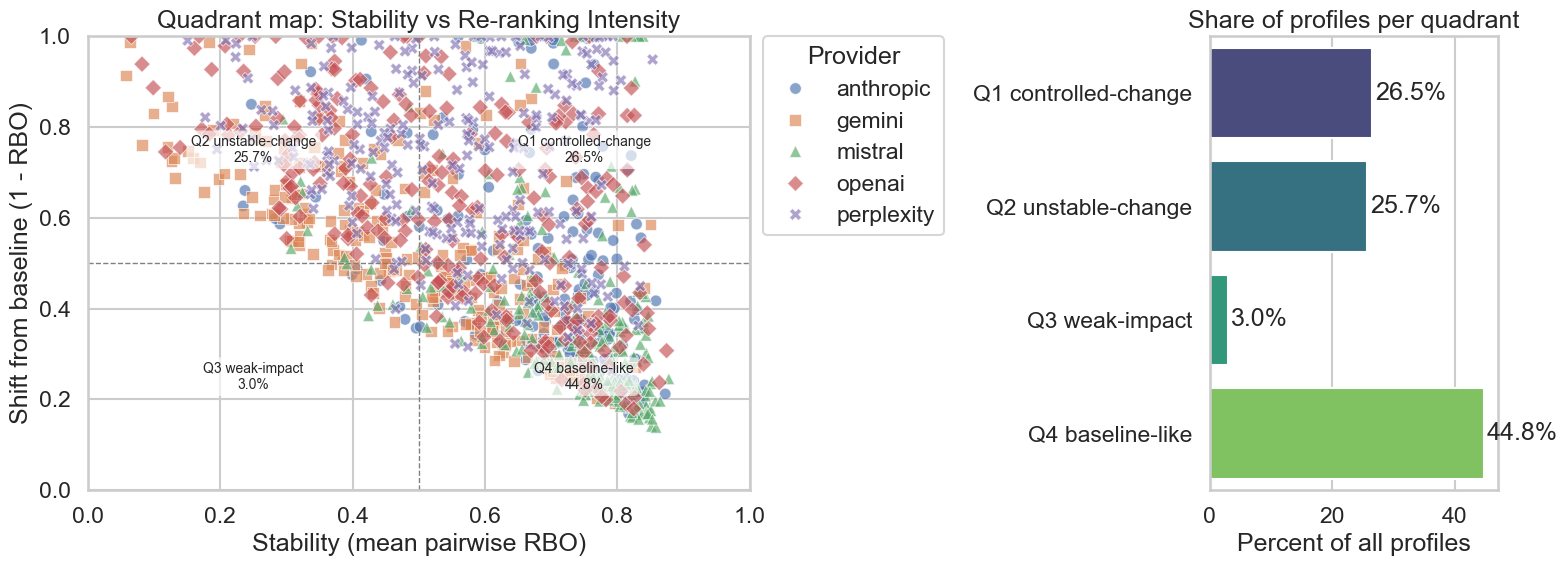

Fixed thresholds -> stability: 0.500, shift: 0.500


quadrant,Q1 controlled-change,Q2 unstable-change,Q3 weak-impact,Q4 baseline-like
provider,,,,
anthropic,25.0,6.9,2.8,65.3
gemini,12.5,40.6,7.4,39.5
mistral,14.5,3.9,2.3,79.3
openai,30.9,37.5,1.6,30.1
perplexity,49.6,36.7,0.8,12.9


In [106]:
# Quadrant assignment + visualization (fixed absolute centroid at 0.5 / 0.5)
x_thr = 0.5
y_thr = 0.5

q = metrics.copy()
q["quadrant"] = np.select(
    [
        (q["stability_rbo"] >= x_thr) & (q["shift_rbo"] >= y_thr),
        (q["stability_rbo"] < x_thr) & (q["shift_rbo"] >= y_thr),
        (q["stability_rbo"] < x_thr) & (q["shift_rbo"] < y_thr),
        (q["stability_rbo"] >= x_thr) & (q["shift_rbo"] < y_thr),
    ],
    ["Q1 controlled-change", "Q2 unstable-change", "Q3 weak-impact", "Q4 baseline-like"],
    default="Unassigned",
)

quad_order = ["Q1 controlled-change", "Q2 unstable-change", "Q3 weak-impact", "Q4 baseline-like"]
quad_pct = (
    q["quadrant"].value_counts(normalize=True)
    .reindex(quad_order)
    .fillna(0)
    .mul(100)
    .rename("percent")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [2.3, 1]})

marker_map = {"anthropic": "o", "gemini": "s", "mistral": "^", "openai": "D", "perplexity": "X"}

sns.scatterplot(
    data=q,
    x="stability_rbo",
    y="shift_rbo",
    hue="provider",
    style="provider",
    markers=marker_map,
    alpha=0.65,
    s=70,
    ax=axes[0],
)

axes[0].axhline(y_thr, color="gray", linestyle="--", linewidth=1)
axes[0].axvline(x_thr, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Quadrant map: Stability vs Re-ranking Intensity")
axes[0].set_xlabel("Stability (mean pairwise RBO)")
axes[0].set_ylabel("Shift from baseline (1 - RBO)")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, title="Provider")

# annotate quadrant percentages near each area
xmin, xmax = axes[0].get_xlim()
ymin, ymax = axes[0].get_ylim()

coords = {
    "Q1 controlled-change": ((x_thr + xmax) / 2, (y_thr + ymax) / 2),
    "Q2 unstable-change": ((xmin + x_thr) / 2, (y_thr + ymax) / 2),
    "Q3 weak-impact": ((xmin + x_thr) / 2, (ymin + y_thr) / 2),
    "Q4 baseline-like": ((x_thr + xmax) / 2, (ymin + y_thr) / 2),
}
for name, (xx, yy) in coords.items():
    axes[0].text(xx, yy, f"{name}\n{quad_pct.get(name, 0):.1f}%", ha="center", va="center", fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.65, edgecolor="none"))

sns.barplot(x=quad_pct.values, y=quad_pct.index, orient="h", ax=axes[1], palette="viridis")
axes[1].set_title("Share of profiles per quadrant")
axes[1].set_xlabel("Percent of all profiles")
axes[1].set_ylabel("")
for i, v in enumerate(quad_pct.values):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.show()

print(f"Fixed thresholds -> stability: {x_thr:.3f}, shift: {y_thr:.3f}")

# Provider-level quadrant composition (for paper tables)
provider_quads = (
    q.groupby(["provider", "quadrant"]).size().reset_index(name="count")
)
provider_quads["pct_within_provider"] = provider_quads.groupby("provider")["count"].transform(lambda s: 100 * s / s.sum())

display(
    provider_quads.pivot(index="provider", columns="quadrant", values="pct_within_provider")
    .reindex(columns=quad_order)
    .fillna(0)
    .style.format("{:.1f}")
)

## 7) Directional interpretation (no hard quadrant cutoffs)

Instead of hard threshold quadrants, this view treats the space continuously:

- Moving **right** means more run-to-run stability.
- Moving **up** means stronger re-ranking vs baseline.
- The **top-right direction** corresponds to stronger controlled criterion influence.

This avoids arbitrary cutoffs while preserving interpretability.

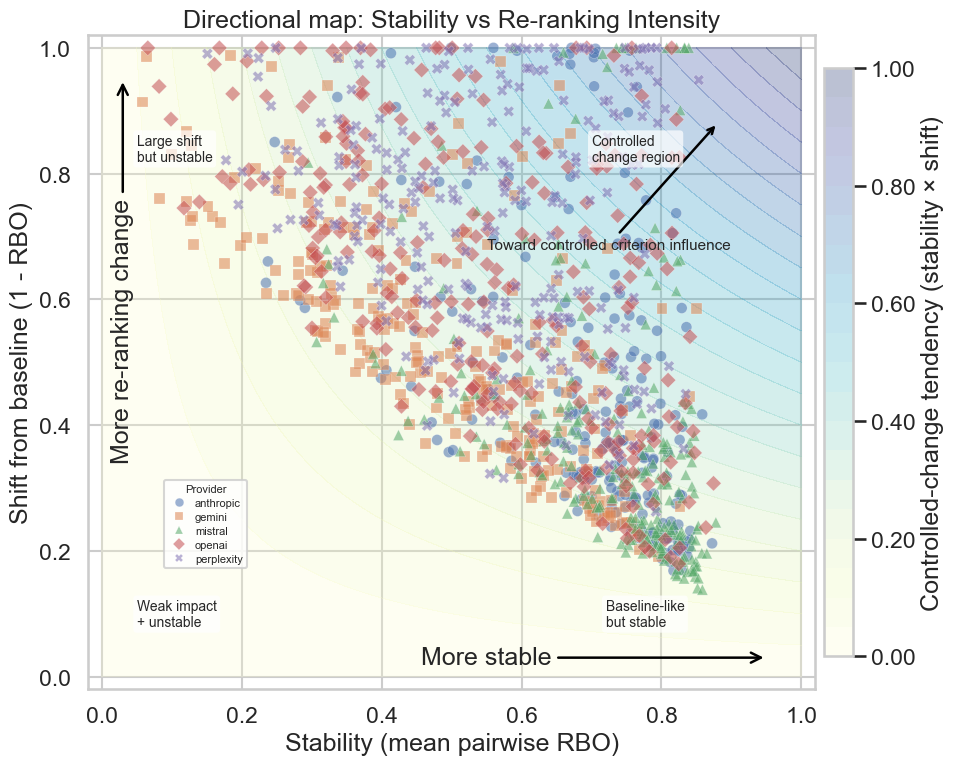

In [ ]:
# Continuous interpretation map (no hard bins)
fig, ax = plt.subplots(figsize=(10, 8))

marker_map = {"anthropic": "o", "gemini": "s", "mistral": "^", "openai": "D", "perplexity": "X"}

# background gradient toward top-right (interpreted as stronger controlled change)
grid_n = 200
x = np.linspace(0, 1, grid_n)
y = np.linspace(0, 1, grid_n)
X, Y = np.meshgrid(x, y)
control_intensity = X * Y

im = ax.contourf(X, Y, control_intensity, levels=20, cmap="YlGnBu", alpha=0.28, vmin=0, vmax=1)
cb = plt.colorbar(im, ax=ax, shrink=0.9, pad=0.01)
cb.set_label("Controlled-change tendency (stability × shift)", fontsize=11)
cb.set_ticks(np.linspace(0, 1, 6))
cb.set_ticklabels([f"{t:.2f}" for t in np.linspace(0, 1, 6)])
cb.ax.tick_params(labelsize=11)

sns.scatterplot(
    data=metrics,
    x="stability_rbo",
    y="shift_rbo",
    hue="provider",
    style="provider",
    markers=marker_map,
    s=62,
    alpha=0.55,
    linewidth=0.3,
    edgecolor="white",
    ax=ax,
)

# Axis semantics and directional arrows
ax.annotate(
    "More stable",
    xy=(0.95, 0.03),
    xytext=(0.55, 0.03),
    arrowprops=dict(arrowstyle="->", lw=1.8, color="black"),
    ha="center",
    va="center",
)
ax.annotate(
    "More re-ranking change",
    xy=(0.03, 0.95),
    xytext=(0.03, 0.55),
    arrowprops=dict(arrowstyle="->", lw=1.8, color="black"),
    ha="center",
    va="center",
    rotation=90,
)
ax.annotate(
    "Toward controlled criterion influence",
    xy=(0.88, 0.88),
    xytext=(0.55, 0.68),
    arrowprops=dict(arrowstyle="->", lw=1.8, color="black"),
    fontsize=11,
)

# Corner interpretation labels (soft, not thresholded)
ax.text(0.05, 0.08, "Weak impact\n+ unstable", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.7, edgecolor="none"))
ax.text(0.72, 0.08, "Baseline-like\nbut stable", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.7, edgecolor="none"))
ax.text(0.05, 0.82, "Large shift\nbut unstable", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.7, edgecolor="none"))
ax.text(0.70, 0.82, "Controlled\nchange region", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.7, edgecolor="none"))

# Small padding prevents visual clipping for points exactly at 0 or 1
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xticks(np.linspace(0, 1, 6))
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_title("Directional map: Stability vs Re-ranking Intensity", fontsize=11)
ax.set_xlabel("Stability (mean pairwise RBO)", fontsize=11)
ax.set_ylabel("Shift from baseline (1 - RBO)", fontsize=11)
ax.tick_params(axis="both", labelsize=11)
ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.1, 0.18),  # keep inside plot, above bottom-left annotation
    borderaxespad=0.3,
    title="Provider",
    frameon=True,
    fontsize=11,
    title_fontsize=11,
    markerscale=0.8,
    handletextpad=0.4,
    labelspacing=0.35,
)
plt.tight_layout()
plt.show()

## 8) Criterion-specific behavior maps (4x4)

To inspect whether each ranking criterion induces a distinct behavior profile, we plot one panel per criterion in the same stability/shift space.

Each subplot shows a 2D density heatmap of profiles `(provider, feature)` for that criterion.

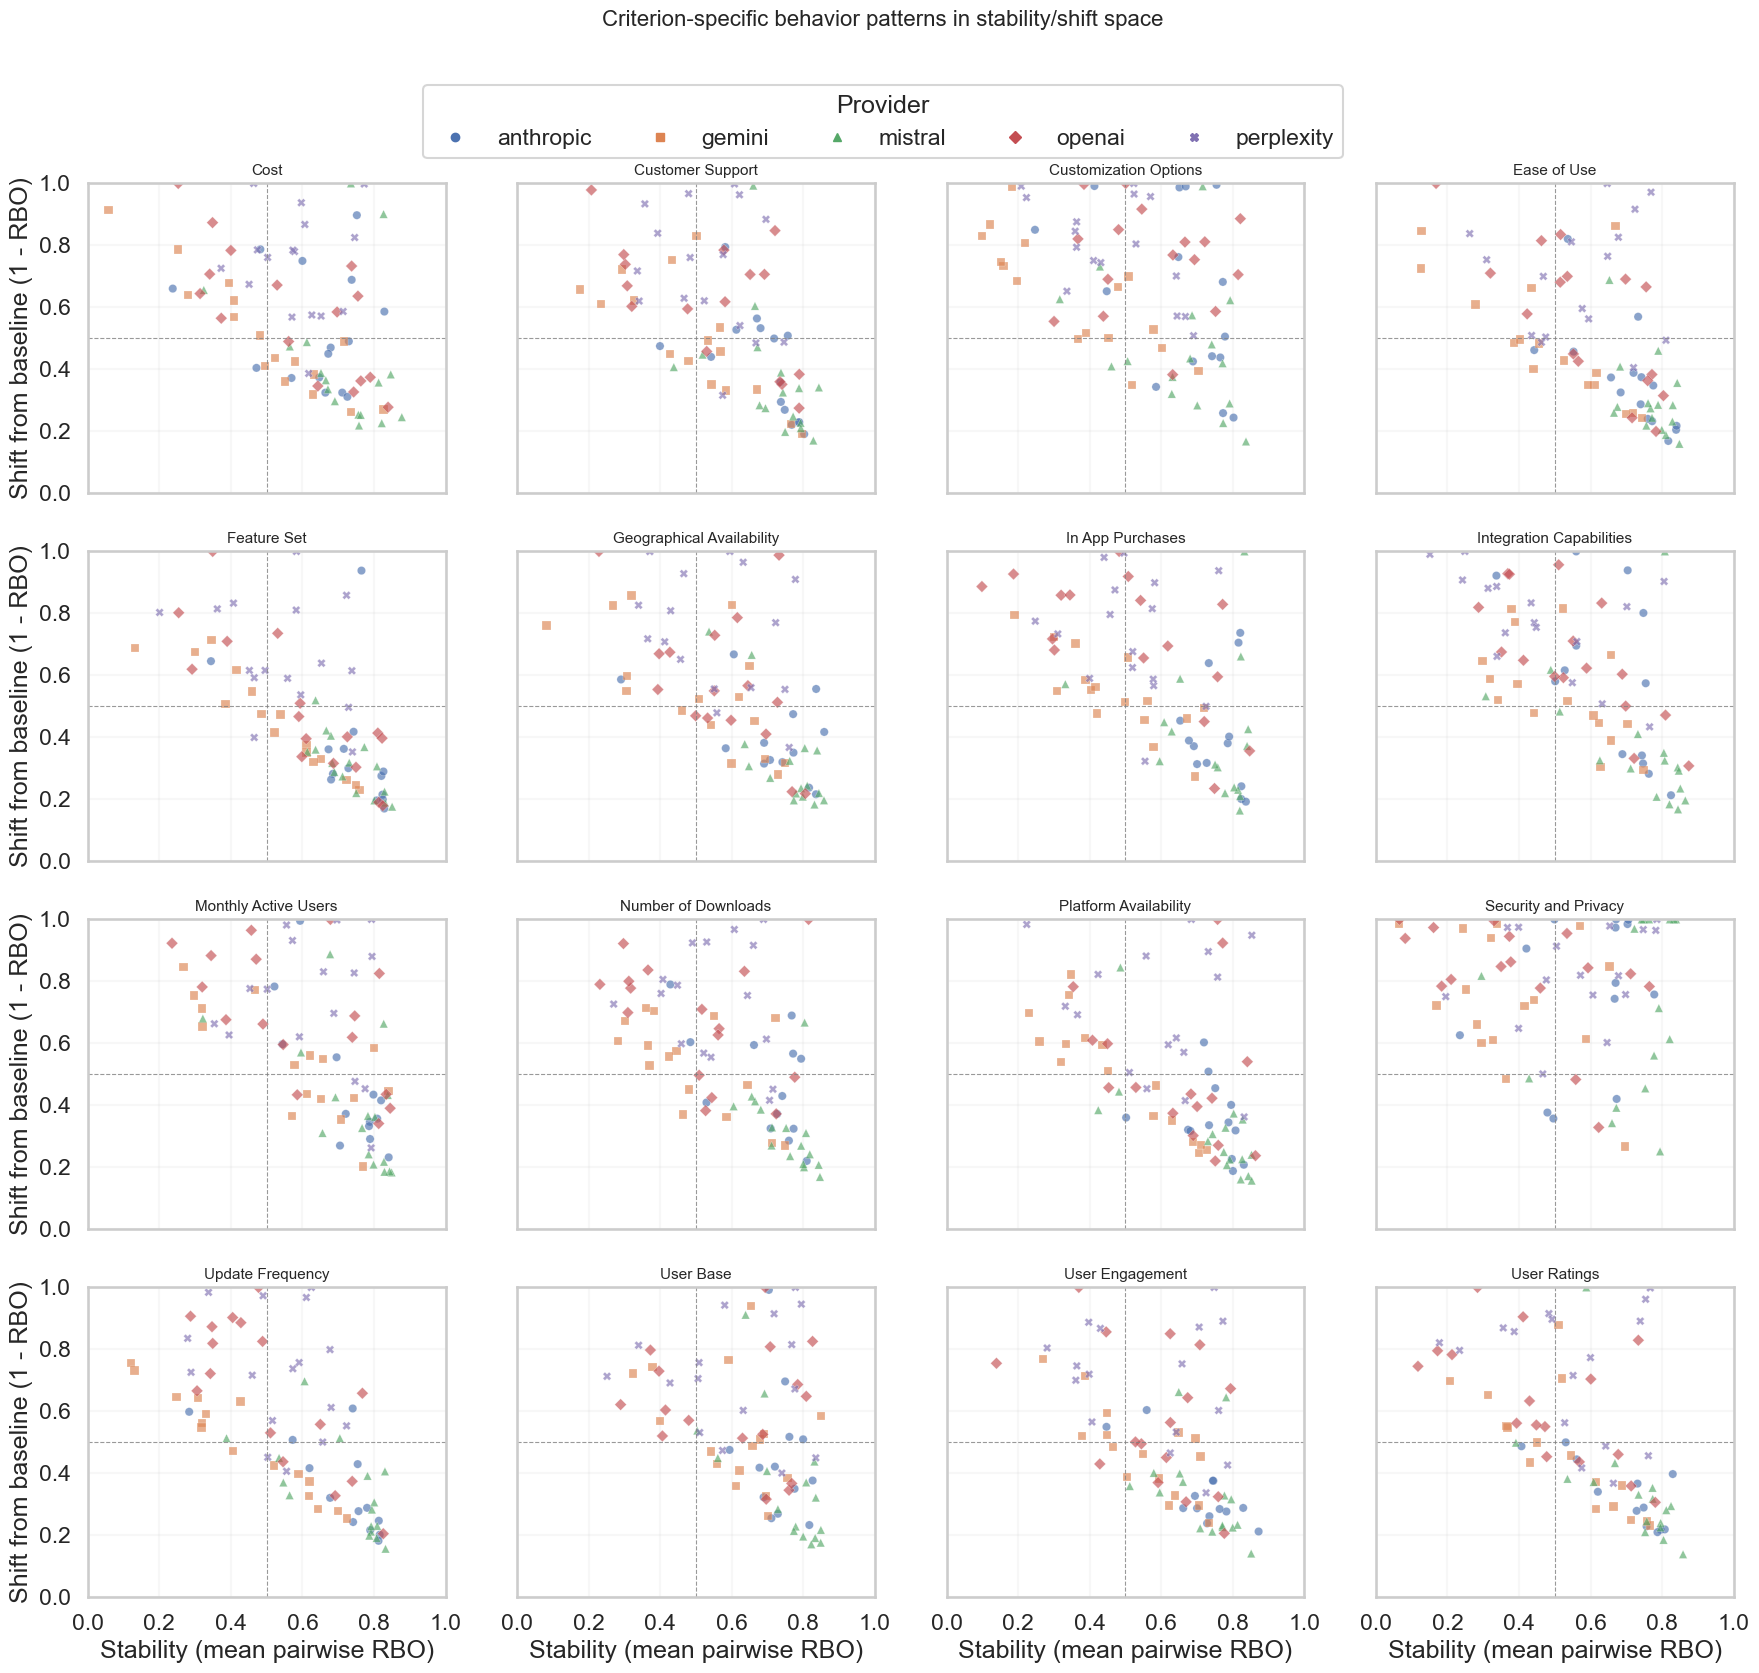

In [110]:
# 4x4 panel: same scatter style, one subplot per criterion
criteria = sorted(metrics["criterion"].dropna().unique())
fig, axes = plt.subplots(4, 4, figsize=(18, 16), sharex=True, sharey=True)
axes = axes.flatten()

marker_map = {"anthropic": "o", "gemini": "s", "mistral": "^", "openai": "D", "perplexity": "X"}
palette = dict(zip(sorted(metrics["provider"].unique()), sns.color_palette("deep", n_colors=metrics["provider"].nunique())))

for i, c in enumerate(criteria):
    ax = axes[i]
    sub = metrics[metrics["criterion"] == c]

    if len(sub) == 0:
        ax.axis("off")
        continue

    sns.scatterplot(
        data=sub,
        x="stability_rbo",
        y="shift_rbo",
        hue="provider",
        style="provider",
        markers=marker_map,
        palette=palette,
        alpha=0.65,
        s=36,
        linewidth=0.25,
        edgecolor="white",
        legend=False,
        ax=ax,
    )

    # fixed absolute reference lines for comparability
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.8)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.8)

    ax.set_title(c.replace("_", " "), fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.15)

# Hide extra axes if needed
for j in range(len(criteria), len(axes)):
    axes[j].axis("off")

for ax in axes[12:16]:
    ax.set_xlabel("Stability (mean pairwise RBO)")
for ax in [axes[0], axes[4], axes[8], axes[12]]:
    ax.set_ylabel("Shift from baseline (1 - RBO)")

# single shared legend (same styles as main plot)
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker=marker_map[p], color=palette[p], linestyle="", markersize=6, label=p)
    for p in sorted(metrics["provider"].unique())
]
fig.legend(handles=handles, title="Provider", loc="upper center", ncol=5, frameon=True, bbox_to_anchor=(0.5, 1.01))

fig.suptitle("Criterion-specific behavior patterns in stability/shift space", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()